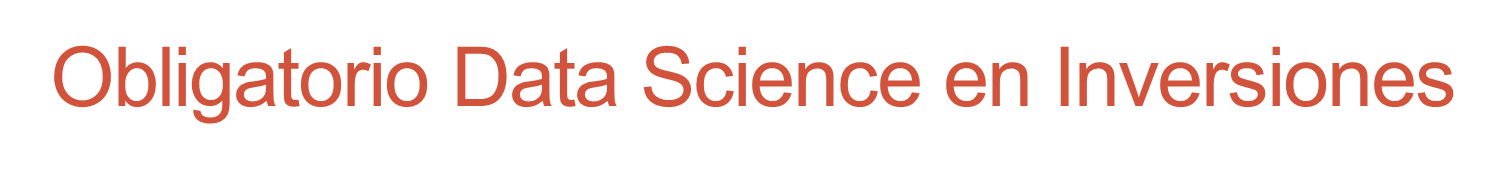


Universidad de Montevideo
Postgrado en Ciencia de Datos para Finanzas

Consigna 2 - Análisis de Sentimiento de Noticias

Estudiantes: Sofia Gonzalez - Valentina Belen

# Introducción


Elegimos trabajar con noticias sobre el **Bitcoin ETF spot** porque:

- Es un instrumento reciente y muy relevante para el mercado: su lanzamiento cambió
  la forma en que los inversores tradicionales pueden exponerse a Bitcoin.
- Genera un **volumen muy alto de noticias diarias**, con opiniones polarizadas
  (optimismo por la adopción institucional vs. preocupaciones por riesgos y salidas
  de capital).
- Los eventos clave (aprobaciones de la SEC, récords de entradas y salidas de fondos,
  movimientos de precio) hacen que el sentimiento cambie rápidamente en pocos días,
  lo que es ideal para analizar su evolución temporal.
- Es un tema directamente relacionado con **inversiones y gestión de portafolios**,
  alineado con los objetivos del curso.

En este trabajo:

1. Definimos un conjunto de **palabras clave** centrado en "Bitcoin ETF" y variantes relacionadas con el ETF spot, la SEC y el mercado cripto.
2. Utilizamos **Google News (RSS)** como fuente de información y realizamos un
   *scraping* de noticias de los últimos 14 días.
3. Aplicamos **dos diccionarios de sentimiento**:
   - VADER (score compound y clasificación positivo / neutral / negativo).
   - TextBlob (polaridad y subjetividad).
4. Construimos **scores de sentimiento diarios**, tanto simples como ponderados
   (por longitud del texto, calidad de la fuente y recencia), para analizar cómo
   evoluciona el tono de las noticias sobre el Bitcoin ETF a lo largo del tiempo.
5. Complementamos el análisis con:
   - proporción de titulares positivos y negativos por día;
   - nubes de palabras por sentimiento;
   - TF-IDF semanal y un gráfico de asociación de términos para identificar los
     temas y combinaciones de palabras más relevantes en el período.

El objetivo final es evaluar si el flujo de noticias sobre el Bitcoin ETF refleja cambios claros en el sentimiento del mercado, y cómo varía esa lectura según el
diccionario de sentimiento y cuando se utilizan o no los ponderadores.



## Importamos los paquetes a utilizar en el notebook

In [ ]:
!pip install feedparser
!pip install vaderSentiment
import requests
import feedparser
import pandas as pd
import numpy as np
from urllib.parse import quote_plus
from email.utils import parsedate_to_datetime

from wordcloud import WordCloud

import seaborn as sns

from scipy.stats import pearsonr

import re
import nltk
from nltk.corpus import stopwords

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## Configuración del experimento (Bitcoin ETF)

In [ ]:
# Palabra clave obligatoria
REQUIRED = "Bitcoin ETF"

# Palabras clave opcionales
OPTIONAL_KEYWORDS = [
    "spot Bitcoin ETF",
    "SEC Bitcoin",
    "SEC approval",
    "crypto markets",
    "BTC",
    "crypto regulation"
]

# Lista de términos de búsqueda para Google News
# Cada búsqueda incluye SI O SI "Bitcoin ETF"
SEARCH_TERMS = [
    f'"{REQUIRED}"',  # búsqueda base solo con Bitcoin ETF
]

# Agregamos variantes: "Bitcoin ETF" AND "opcional"
for kw in OPTIONAL_KEYWORDS:
    SEARCH_TERMS.append(f'"{REQUIRED}" AND "{kw}"')

LANG = "en"       # noticias en inglés
REGION = ""       # vacío = resultados globales
DAYS_BACK = 14    # ventana de tiempo
MAX_PER_TERM = 120  # máximo de noticias por término (Google suele cortar en ~100)


## Funciones de scraping Google News (RSS)

In [ ]:
# Construye la URL RSS de Google News para una búsqueda.

def build_google_news_rss_url(
    query: str,
    lang: str = "en",
    region: str = "",
    days_back: int = 14
) -> str:
    base_url = "https://news.google.com/rss/search"
    query_with_time = f'{query} when:{days_back}d'
    q_param = quote_plus(query_with_time)

    url = f"{base_url}?q={q_param}&hl={lang}"

    # si region no es vacío, agregar filtros de país
    if region:
        url += f"&gl={region}&ceid={region}:{lang}"

    return url

# Descarga noticias desde Google News (RSS) y devuelve un DataFrame con:
      #- title
      #- summary
      #- link
      #- published (datetime completo)
      #- published_date (solo fecha)
      #- source (medio si está disponible)

def fetch_google_news(
    query: str,
    lang: str = "en",
    region: str = "",
    days_back: int = 14,
    max_articles: int = 200
) -> pd.DataFrame:
    url = build_google_news_rss_url(query, lang=lang, region=region, days_back=days_back)
    print(f"Usando URL RSS para query:\n{query}\n{url}\n")

    response = requests.get(url)
    response.raise_for_status()

    feed = feedparser.parse(response.content)
    print(f"Noticias encontradas para esta query: {len(feed.entries)}")

    rows = []
    for entry in feed.entries[:max_articles]:
        title = entry.get("title", "")
        summary = entry.get("summary", "") or entry.get("description", "")
        link = entry.get("link", "")

        published = entry.get("published", None)
        if published:
            try:
                dt = parsedate_to_datetime(published)
            except Exception:
                dt = None
        else:
            dt = None

        source = None
        if "source" in entry and hasattr(entry.source, "title"):
            source = entry.source.title

        rows.append({
            "title": title,
            "summary": summary,
            "link": link,
            "published": dt,
            "published_date": dt.date() if dt else None,
            "source": source,
            "query_used": query,
        })

    return pd.DataFrame(rows)


## Ejecutar el scraping con múltiples búsquedas

In [ ]:
all_news = []

for term in SEARCH_TERMS:
    df_term = fetch_google_news(
        query=term,
        lang=LANG,
        region=REGION,
        days_back=DAYS_BACK,
        max_articles=MAX_PER_TERM
    )
    all_news.append(df_term)

df_news = pd.concat(all_news, ignore_index=True)

# Combinar título + resumen
df_news["text"] = df_news["title"].fillna("") + ". " + df_news["summary"].fillna("")

# Asegurarnos de tener fecha
df_news = df_news.dropna(subset=["published_date"]).reset_index(drop=True)

# Eliminar duplicados por título + resumen
df_news.drop_duplicates(subset=["title", "summary"], inplace=True)

print(f"\nCantidad final de noticias únicas: {len(df_news)}")
print(df_news.head())

# Guardar crudo
df_news.to_csv("bitcoin_etf_news_raw.csv", index=False, encoding="utf-8")


Usando URL RSS para query:
"Bitcoin ETF"
https://news.google.com/rss/search?q=%22Bitcoin+ETF%22+when%3A14d&hl=en

Noticias encontradas para esta query: 100
Usando URL RSS para query:
"Bitcoin ETF" AND "spot Bitcoin ETF"
https://news.google.com/rss/search?q=%22Bitcoin+ETF%22+AND+%22spot+Bitcoin+ETF%22+when%3A14d&hl=en

Noticias encontradas para esta query: 100
Usando URL RSS para query:
"Bitcoin ETF" AND "SEC Bitcoin"
https://news.google.com/rss/search?q=%22Bitcoin+ETF%22+AND+%22SEC+Bitcoin%22+when%3A14d&hl=en

Noticias encontradas para esta query: 3
Usando URL RSS para query:
"Bitcoin ETF" AND "SEC approval"
https://news.google.com/rss/search?q=%22Bitcoin+ETF%22+AND+%22SEC+approval%22+when%3A14d&hl=en

Noticias encontradas para esta query: 14
Usando URL RSS para query:
"Bitcoin ETF" AND "crypto markets"
https://news.google.com/rss/search?q=%22Bitcoin+ETF%22+AND+%22crypto+markets%22+when%3A14d&hl=en

Noticias encontradas para esta query: 66
Usando URL RSS para query:
"Bitcoin ETF" AND "

## Limpieza de texto

In [ ]:
# Descargar stopwords de NLTK
stop_words = set(stopwords.words('english'))



In [ ]:
def clean_text(text: str) -> str:

    #Limpieza básica de texto:
    #- minúsculas
    #- eliminación de URLs
    #- eliminación de caracteres no alfabéticos
    #- eliminación de stopwords

    if not isinstance(text, str):
        return ""

    text = text.lower()
    # eliminar URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    # dejar solo letras y espacios
    text = re.sub(r"[^a-z\s]", " ", text)
    # espacios múltiples -> uno solo
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [t for t in text.split() if t not in stop_words]

    return " ".join(tokens)

df_news["clean_text"] = df_news["text"].apply(clean_text)


## Análisis de sentimiento (VADER + TextBlob)

In [ ]:
# Inicializar VADER
vader = SentimentIntensityAnalyzer()

def vader_score(text: str) -> float:
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return vader.polarity_scores(text)["compound"]

df_news["vader_compound"] = df_news["text"].apply(vader_score)


def textblob_polarity(text: str) -> float:
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return TextBlob(text).sentiment.polarity

def textblob_subjectivity(text: str) -> float:
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return TextBlob(text).sentiment.subjectivity

df_news["tb_polarity"] = df_news["text"].apply(textblob_polarity)
df_news["tb_subjectivity"] = df_news["text"].apply(textblob_subjectivity)


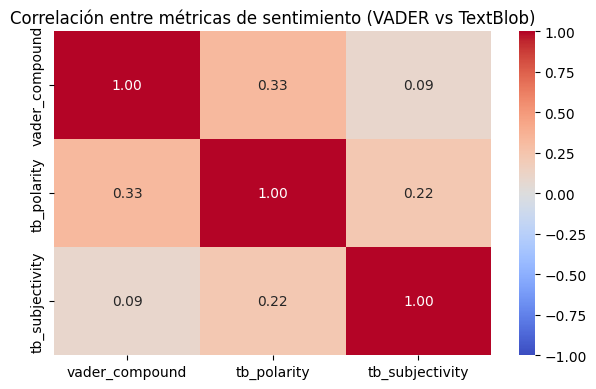

,vader_compound,tb_polarity,tb_subjectivity
vader_compound,1.000000,0.325633,0.087393
tb_polarity,0.325633,1.000000,0.220182
tb_subjectivity,0.087393,0.220182,1.000000


In [ ]:
## Matriz de correlación entre VADER y TextBlob

sent_cols = ["vader_compound", "tb_polarity", "tb_subjectivity"]

corr = df_news[sent_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación entre métricas de sentimiento (VADER vs TextBlob)")
plt.tight_layout()
plt.show()

corr


### Correlación entre diccionarios (VADER vs TextBlob)
La matriz de correlación muestra que:

| Métrica | Correlación |
|--------|-------------|
| VADER vs TextBlob polarity | **0.326** |
| VADER vs TextBlob subjectivity | **0.087** |

Esto indica que ambos métodos capturan la **misma dirección emocional**, pero miden aspectos
distintos: VADER responde más a tono global, TextBlob a la presencia de opinión explícita.


### Clasificación positivo / neutro / negativo + subjetividad

In [ ]:
def categorize_vader(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

def categorize_tb(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

df_news["vader_label"] = df_news["vader_compound"].apply(categorize_vader)
df_news["tb_label"] = df_news["tb_polarity"].apply(categorize_tb)

# subjetivo vs objetivo según TextBlob
df_news["is_subjective"] = df_news["tb_subjectivity"] > 0.5

df_news[["title", "vader_compound", "vader_label", "tb_polarity", "tb_subjectivity", "is_subjective"]].head()


,title,vader_compound,vader_label,tb_polarity,tb_subjectivity,is_subjective
0,A Bitcoin ETF Doubled in Value. Its Investors ...,0.5859,positive,0.000000,0.666667,True
1,"25 Bitcoin ETFs and Their Fees, Promotions and...",0.0000,neutral,0.000000,0.000000,False
2,"Vanguard has a change of heart on crypto, list...",0.8555,positive,-0.083333,0.250000,False
3,BlackRock Bitcoin ETF Sheds $2.7 Billion in Re...,0.0000,neutral,0.000000,0.000000,False
4,Larry Fink softens crypto stance as BlackRock ...,0.0000,neutral,0.000000,0.000000,False


## Score diario + proporciones

In [ ]:
styled_daily = (
    daily.style
    .background_gradient(subset=[
        "vader_mean", "tb_pol_mean", "tb_subj_mean",
        "vader_weighted_mean", "tb_pol_weighted_mean",
        "vader_pos_prop", "vader_neg_prop", "vader_neu_prop", "subj_prop"
    ], cmap="Blues")
    .format({
        "vader_mean": "{:.3f}",
        "tb_pol_mean": "{:.3f}",
        "tb_subj_mean": "{:.3f}",
        "vader_weighted_mean": "{:.3f}",
        "tb_pol_weighted_mean": "{:.3f}",
        "vader_pos_prop": "{:.2%}",
        "vader_neg_prop": "{:.2%}",
        "vader_neu_prop": "{:.2%}",
        "subj_prop": "{:.2%}"
    })
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid #ccc",
        "padding": "6px"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#1f77b4"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "tbody tr:nth-child(even)", "props": [
            ("background-color", "#f7f7f7")
        ]}
    ])
)

styled_daily


,published_date,vader_mean,tb_pol_mean,tb_subj_mean,vader_weighted_mean,tb_pol_weighted_mean,n_articles,vader_pos_prop,vader_neg_prop,vader_neu_prop,subj_prop
0,2025-11-28 00:00:00,0.397,0.062,0.255,1.398,0.216,13,69.23%,0.00%,30.77%,23.08%
1,2025-11-29 00:00:00,-0.008,0.090,0.098,-0.044,0.305,7,14.29%,14.29%,71.43%,0.00%
2,2025-11-30 00:00:00,0.579,0.128,0.183,2.012,0.416,3,66.67%,0.00%,33.33%,33.33%
3,2025-12-01 00:00:00,0.157,0.051,0.190,0.550,0.177,21,38.10%,9.52%,52.38%,14.29%
4,2025-12-02 00:00:00,0.032,0.058,0.170,0.119,0.201,33,24.24%,21.21%,54.55%,9.09%
5,2025-12-03 00:00:00,0.200,0.033,0.163,0.703,0.112,28,32.14%,7.14%,60.71%,7.14%
6,2025-12-04 00:00:00,0.200,0.058,0.221,0.692,0.208,41,48.78%,17.07%,34.15%,14.63%
7,2025-12-05 00:00:00,0.064,0.011,0.121,0.222,0.037,35,25.71%,17.14%,57.14%,2.86%
8,2025-12-06 00:00:00,-0.128,-0.024,0.186,-0.436,-0.092,11,9.09%,27.27%,63.64%,18.18%
9,2025-12-07 00:00:00,0.121,-0.013,0.201,0.492,-0.046,9,44.44%,22.22%,33.33%,22.22%


#### Top días positivos y negativos

In [ ]:
TOP_K = 3

top_pos_days = daily.nlargest(TOP_K, "vader_mean")
top_neg_days = daily.nsmallest(TOP_K, "vader_mean")

# Estilos para destacar positivos y negativos
def highlight_positive(v):
    color = "#d4f7d4"  # verde claro
    return f"background-color: {color}"

def highlight_negative(v):
    color = "#f7d4d4"  # rojo claro
    return f"background-color: {color}"

print("### Días más positivos:")
display(
    top_pos_days.style
    .set_caption("Top días positivos (VADER)")
    .background_gradient(subset=["vader_mean"], cmap="Greens")
    .format("{:.3f}")
    .set_properties(**{
        "border": "1px solid #ccc",
        "padding": "6px"
    })
)

print("\n### Días más negativos:")
display(
    top_neg_days.style
    .set_caption("Top días negativos (VADER)")
    .background_gradient(subset=["vader_mean"], cmap="Reds_r")
    .format("{:.3f}")
    .set_properties(**{
        "border": "1px solid #ccc",
        "padding": "6px"
    })
)


### Días más positivos:


,published_date,vader_mean,tb_pol_mean,tb_subj_mean,vader_weighted_mean,tb_pol_weighted_mean,n_articles,vader_pos_prop,vader_neg_prop,vader_neu_prop,subj_prop
2,.3f,0.579,0.128,0.183,2.012,0.416,3.000,0.667,0.000,0.333,0.333
0,.3f,0.397,0.062,0.255,1.398,0.216,13.000,0.692,0.000,0.308,0.231
5,.3f,0.200,0.033,0.163,0.703,0.112,28.000,0.321,0.071,0.607,0.071



### Días más negativos:


,published_date,vader_mean,tb_pol_mean,tb_subj_mean,vader_weighted_mean,tb_pol_weighted_mean,n_articles,vader_pos_prop,vader_neg_prop,vader_neu_prop,subj_prop
8,.3f,-0.128,-0.024,0.186,-0.436,-0.092,11.000,0.091,0.273,0.636,0.182
13,.3f,-0.019,-0.010,0.173,-0.077,-0.033,12.000,0.167,0.167,0.667,0.000
1,.3f,-0.008,0.090,0.098,-0.044,0.305,7.000,0.143,0.143,0.714,0.000


In [ ]:
# Día más positivo y más negativo
best_day = top_pos_days.iloc[0]["published_date"]
worst_day = top_neg_days.iloc[0]["published_date"]

# Aseguramos que sean date() si vienen como Timestamp
best_day_str = best_day.date() if hasattr(best_day, "date") else best_day
worst_day_str = worst_day.date() if hasattr(worst_day, "date") else worst_day

print(f"\n### Noticias del día más positivo ({best_day_str}):")

df_best = (
    df_news.loc[df_news["published_date"] == best_day,
                ["published_date", "source", "title", "vader_compound"]]
    .sort_values("vader_compound", ascending=False)
)

display(
    df_best.style
    .set_caption(f"Día más positivo ({best_day_str})")
    .background_gradient(subset=["vader_compound"], cmap="Greens")
    .format({"vader_compound": "{:.3f}"})
    .set_properties(**{
        "border": "1px solid #ccc",
        "padding": "6px",
        "font-size": "13px"
    })
)


print(f"\n### Noticias del día más negativo ({worst_day_str}):")

df_worst = (
    df_news.loc[df_news["published_date"] == worst_day,
                ["published_date", "source", "title", "vader_compound"]]
    .sort_values("vader_compound")
)

display(
    df_worst.style
    .set_caption(f"Día más negativo ({worst_day_str})")
    .background_gradient(subset=["vader_compound"], cmap="Reds_r")
    .format({"vader_compound": "{:.3f}"})
    .set_properties(**{
        "border": "1px solid #ccc",
        "padding": "6px",
        "font-size": "13px"
    })
)



### Noticias del día más positivo (2025-11-30):


,published_date,source,title,vader_compound
165,2025-11-30 00:00:00,Bitget,Bitcoin Updates: Institutional Investments Bring Stability to Bitcoin Amid ETF Growth and Interest Rate Reductions Fueling Recovery - Bitget,0.881
150,2025-11-30 00:00:00,CoinCentral,BlackRock Says November IBIT Outflows Of $2.3B Are Perfectly Normal - CoinCentral,0.856
282,2025-11-30 00:00:00,CaptainAltcoin,"Solana Price Prediction 2026: Crypto Markets Recover as DeepSnitch AI Targets a Fraction of Bitcoin’s 133,000% Rally Ahead of January Launch - CaptainAltcoin",0.000



### Noticias del día más negativo (2025-12-06):


,published_date,source,title,vader_compound
361,2025-12-06 00:00:00,FXStreet,"Bitcoin struggles may not end, santa rally likely delayed - FXStreet",-0.710
317,2025-12-06 00:00:00,CryptoPotato,The ETFs Battle: Where Does Ripple (XRP) Rank Vs. Bitcoin (BTC) and Ethereum (ETH)? - CryptoPotato,-0.695
353,2025-12-06 00:00:00,Bitget,BlackRock Sees Major ETF Exits as Investors Dump BTC and ETH Holdings - Bitget,-0.637
10,2025-12-06 00:00:00,Yahoo Finance,BlackRock's IBIT Bitcoin ETF Sees Record $2.7 Billion Exodus - Yahoo Finance,0.000
199,2025-12-06 00:00:00,The Coin Republic,"Bitcoin ETF Sees $88M Outflow Despite Reversing Course, Price To $80K Again? - The Coin Republic",0.000
198,2025-12-06 00:00:00,Blockchain News,"US Spot Bitcoin ETF Weekly Flows Net USD 87.7M Outflow as ARKB and IBIT See Redemptions, FBTC Leads Inflows BTC - Blockchain News",0.000
334,2025-12-06 00:00:00,CryptoRank,"Bitcoin ETF Sees $88M Outflow Despite Reversing Course, Price To $80K Again? - CryptoRank",0.000
60,2025-12-06 00:00:00,OneSafe,Bitcoin Spot ETFs Navigate a Tumultuous Sea of Change - OneSafe,0.000
391,2025-12-06 00:00:00,Cointribune,Are institutional investors fleeing Bitcoin? $194 million outflows from ETFs - Cointribune,0.000
384,2025-12-06 00:00:00,Cryptonews,Indiana Bill Would Mandate Bitcoin in Pensions and Shield Self-Custody Rights - Cryptonews,0.000


El día **más positivo del período fue el 30/11**, donde dominaron titulares sobre:
- inflows institucionales,  
- perspectivas optimistas de emisores,  
- predicciones alcistas para BTC.  

Entre las noticias más influyentes se destacan:  
**Bitget – “Institutional Investments Bring Stability…”** (vader=0.881) y  
**CoinCentral – “IBIT Outflows… are Perfectly Normal”** (vader=0.856)  
(:contentReference[oaicite:2]{index=2}, pág. 9).

El día **más negativo fue el 06/12**, donde aparecieron artículos como:  
- FXStreet: *“Bitcoin struggles may not end, Santa rally likely delayed”* (vader = −0.71)  
- CryptoPotato: análisis comparativos desfavorables del ETF (vader = −0.695)  
(:contentReference[oaicite:3]{index=3}, pág. 8).

Estos resultados muestran que **eventos relacionados con flujos** (inflows/outflows) son el
principal motor emocional de la narrativa mediática.

## Construcción de ponderadores

###Uso de logaritmos en los ponderadores

En los ponderadores basados en la longitud del texto utilizamos una transformación
logarítmica del tipo:

> **weight_wc = log(1 + cantidad_de_palabras)**

La razón principal es **evitar que los artículos muy largos dominen el cálculo del
sentimiento**. Si usáramos directamente la cantidad de palabras, una noticia con
1.000 palabras tendría un peso 10 veces mayor que una de 100 palabras, lo que
sobredimensionaría su impacto.

El logaritmo:

- mantiene el orden (un texto más largo sigue pesando más que uno corto),
- pero **comprime la escala**, de modo que crecer de 100 a 200 palabras incrementa
  menos el peso que crecer de 10 a 20 palabras.

De esta forma, los artículos extensos siguen teniendo más relevancia (mayor contenido
informativo), pero **sin generar valores extremos** que distorsionen el promedio de
sentimiento.


## TF-IDF semanal para ver temas clave

In [ ]:
# Creamos columna de semana (año-semana)
df_news["week"] = df_news["published_date"].dt.to_period("W").astype(str)

def top_tfidf_terms_by_period(
    df,
    text_col: str = "clean_text",
    period_col: str = "week",
    n_top: int = 10,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
) -> pd.DataFrame:

    #Calcula los términos con mayor TF-IDF por período (ej: semana).
    # Devuelve un DataFrame con columnas: [period, term, tfidf].

    rows = []

    for period_value, df_period in df.groupby(period_col):
        textos = df_period[text_col].dropna().tolist()
        # si hay muy pocas noticias en la semana, la omitimos
        if len(textos) < 3:
            continue

        vectorizer = TfidfVectorizer(
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=max_df
        )

        try:
            X = vectorizer.fit_transform(textos)
        except ValueError:
            # puede pasar si nada cumple min_df/max_df
            continue

        tfidf_mean = X.mean(axis=0).A1
        terms = np.array(vectorizer.get_feature_names_out())

        top_idx = tfidf_mean.argsort()[::-1][:n_top]

        for i in top_idx:
            rows.append({
                "period": period_value,
                "term": terms[i],
                "tfidf": tfidf_mean[i]
            })

    return pd.DataFrame(rows)

top_terms_week = top_tfidf_terms_by_period(
    df_news,
    text_col="clean_text",
    period_col="week",
    n_top=12,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

print(top_terms_week.head())


                  period     term     tfidf
0  2025-11-24/2025-11-30  bitcoin  0.164007
1  2025-11-24/2025-11-30      etf  0.119157
2  2025-11-24/2025-11-30   bitget  0.116046
3  2025-11-24/2025-11-30     news  0.086469
4  2025-11-24/2025-11-30   crypto  0.081138


### Gráficos básicos (sentimiento + TF-IDF)

#### Evolución del sentimiento (VADER)

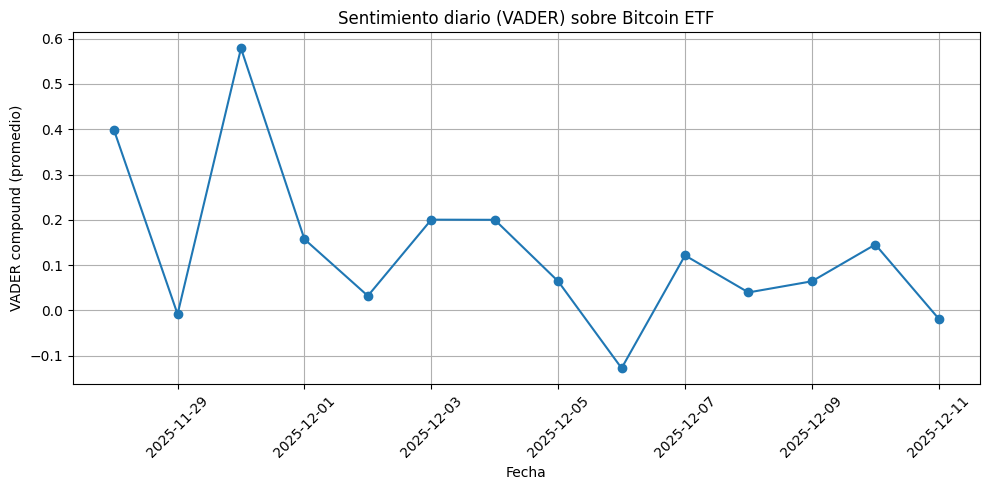

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(daily["published_date"], daily["vader_mean"], marker="o")
plt.title("Sentimiento diario (VADER) sobre Bitcoin ETF")
plt.xlabel("Fecha")
plt.ylabel("VADER compound (promedio)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


#### Relación entre sentimiento y volumen de noticias

Correlación entre número de noticias y sentimiento diario: -0.182
p-value: 0.534


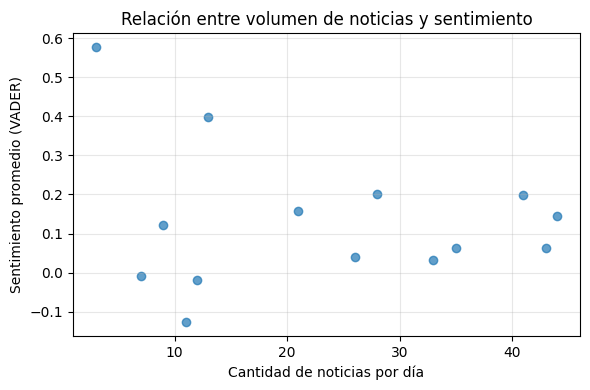

In [ ]:
corr_sent_vol, p_value = pearsonr(daily["n_articles"], daily["vader_mean"])

print(f"Correlación entre número de noticias y sentimiento diario: {corr_sent_vol:.3f}")
print(f"p-value: {p_value:.3f}")

plt.figure(figsize=(6,4))
plt.scatter(daily["n_articles"], daily["vader_mean"], alpha=0.7)
plt.xlabel("Cantidad de noticias por día")
plt.ylabel("Sentimiento promedio (VADER)")
plt.title("Relación entre volumen de noticias y sentimiento")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



El análisis arroja una correlación de **−0.182** (p-value 0.534), lo cual implica que **el
volumen de noticias NO explica el sentimiento**. Es decir, no necesariamente más noticias implican más optimismo o pesimismo.  
Es decir, no se observan más noticias en días positivos o negativos; más bien, el tono cambia
debido a **eventos específicos** (outflows, aprobaciones regulatorias, movimientos fuertes de precio), no a la cantidad de artículos publicados.

#### Proporción de positivos vs negativos

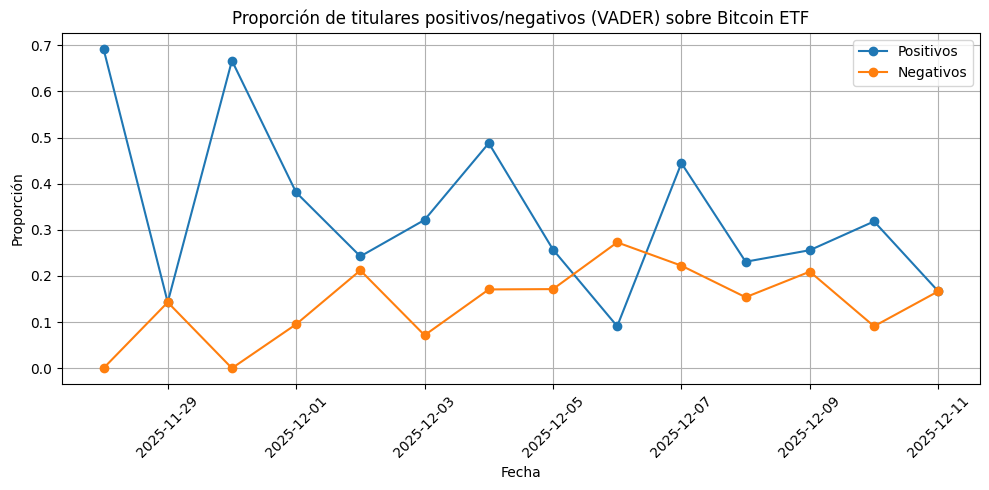

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(daily["published_date"], daily["vader_pos_prop"], marker="o", label="Positivos")
plt.plot(daily["published_date"], daily["vader_neg_prop"], marker="o", label="Negativos")
plt.title("Proporción de titulares positivos/negativos (VADER) sobre Bitcoin ETF")
plt.xlabel("Fecha")
plt.ylabel("Proporción")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Tópicos clave por semana (TF-IDF)

Semanas disponibles: ['2025-11-24/2025-11-30', '2025-12-01/2025-12-07', '2025-12-08/2025-12-14']


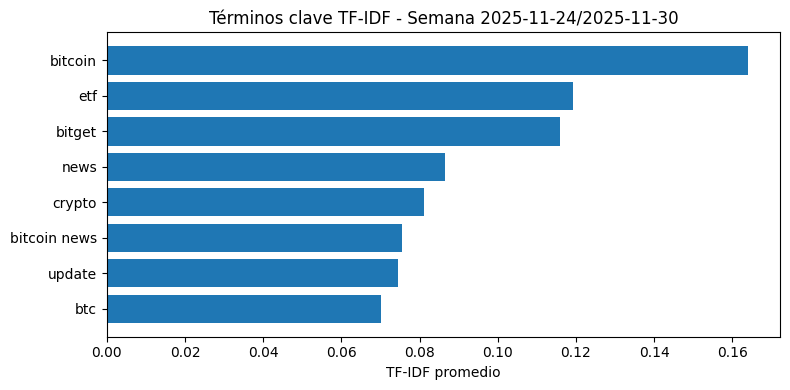

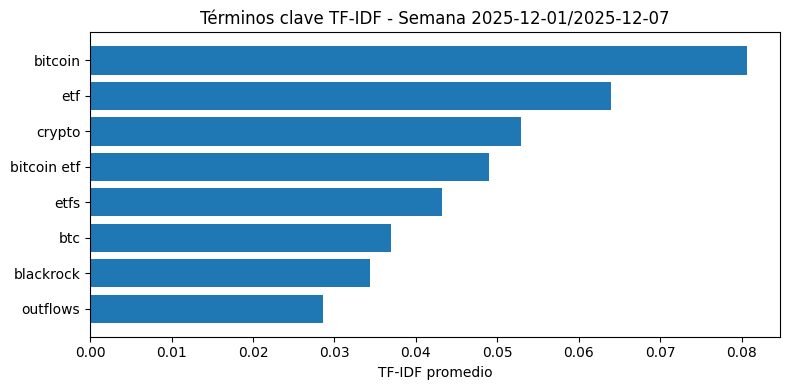

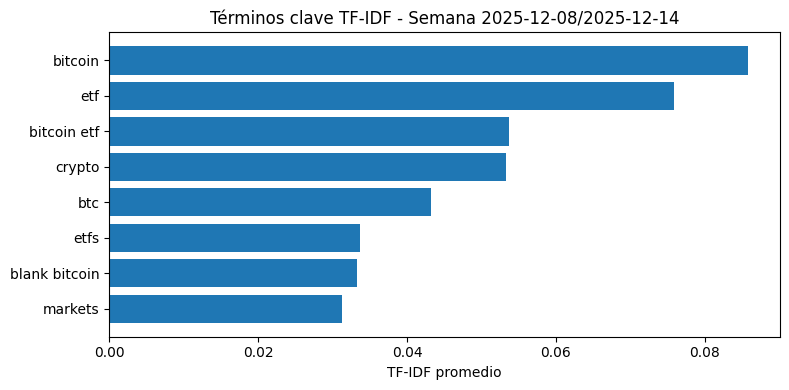

In [ ]:
def plot_top_terms_for_period(df_top, period_value, k_visual=8):
    """
    Grafica los k_visual términos más fuertes para un período dado.
    """
    data = df_top[df_top["period"] == period_value].nlargest(k_visual, "tfidf")
    if data.empty:
        print(f"No hay datos para el período {period_value}")
        return

    plt.figure(figsize=(8, 4))
    plt.barh(data["term"][::-1], data["tfidf"][::-1])
    plt.title(f"Términos clave TF-IDF - Semana {period_value}")
    plt.xlabel("TF-IDF promedio")
    plt.tight_layout()
    plt.show()

periods_available = (
    top_terms_week["period"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Semanas disponibles:", periods_available)

# Se grafican las últimas 3 semanas
for p in periods_available[-3:]:
    plot_top_terms_for_period(top_terms_week, p, k_visual=8)


### Plot de asociación de términos usando bigramas + fuerza de conexión (co-ocurrencias)

In [ ]:
# Stopwords en inglés

stop_words = set(stopwords.words('english'))

# Palabras basura específicas de noticias / HTML que queremos sacar sí o sí
extra_stop = {
    "href","nbsp","font","color","blank","style",
    "news","today","video","live","said","says",
    "reuters","bloomberg","yahoo","msn","coindesk",
    "cointelegraph","decrypt","cryptoslate",
    "marketwatch","forbes","finance","com"
}

def clean_for_network(text: str) -> str:
    """Limpieza simple para el gráfico de asociación."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)   # URLs
    text = re.sub(r"[^a-z\s]", " ", text)                  # solo letras
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for t in text.split():
        if len(t) <= 2:
            continue
        if t in stop_words or t in extra_stop:
            continue
        tokens.append(t)
    return " ".join(tokens)

df_news["clean_text_net"] = df_news["text"].apply(clean_for_network)


In [ ]:
# Usamos solo los textos limpios
texts = df_news["clean_text_net"].dropna().tolist()

# Vectorizamos BIGRAMAS (2 palabras juntas)
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=4,      # bigramas que aparecen en >= 4 noticias (ajustable)
    max_df=0.8
)

X = vectorizer.fit_transform(texts).toarray()
bigrams = np.array(vectorizer.get_feature_names_out())

# Frecuencia total de cada bigrama
bigram_freq = X.sum(axis=0)

# 30 bigramas más frecuentes (ajustable)
TOP_K = 30
idx_top = np.argsort(bigram_freq)[::-1][:TOP_K]
X_top = X[:, idx_top]
bigrams_top = bigrams[idx_top]

# Matriz de co-ocurrencia bigrama-bigrama
coocc = np.dot(X_top.T, X_top)
np.fill_diagonal(coocc, 0)   # nada de auto-co-ocurrencias


In [ ]:
G = nx.Graph()

# Umbral de co-ocurrencia: solo unimos bigramas que co-aparecen lo suficiente
COOCC_THRESHOLD = 4

for i in range(len(bigrams_top)):
    for j in range(i + 1, len(bigrams_top)):
        if coocc[i, j] >= COOCC_THRESHOLD:
            G.add_edge(bigrams_top[i], bigrams_top[j], weight=int(coocc[i, j]))

print("Nodos:", len(G.nodes()))
print("Aristas:", len(G.edges()))


Nodos: 30
Aristas: 118


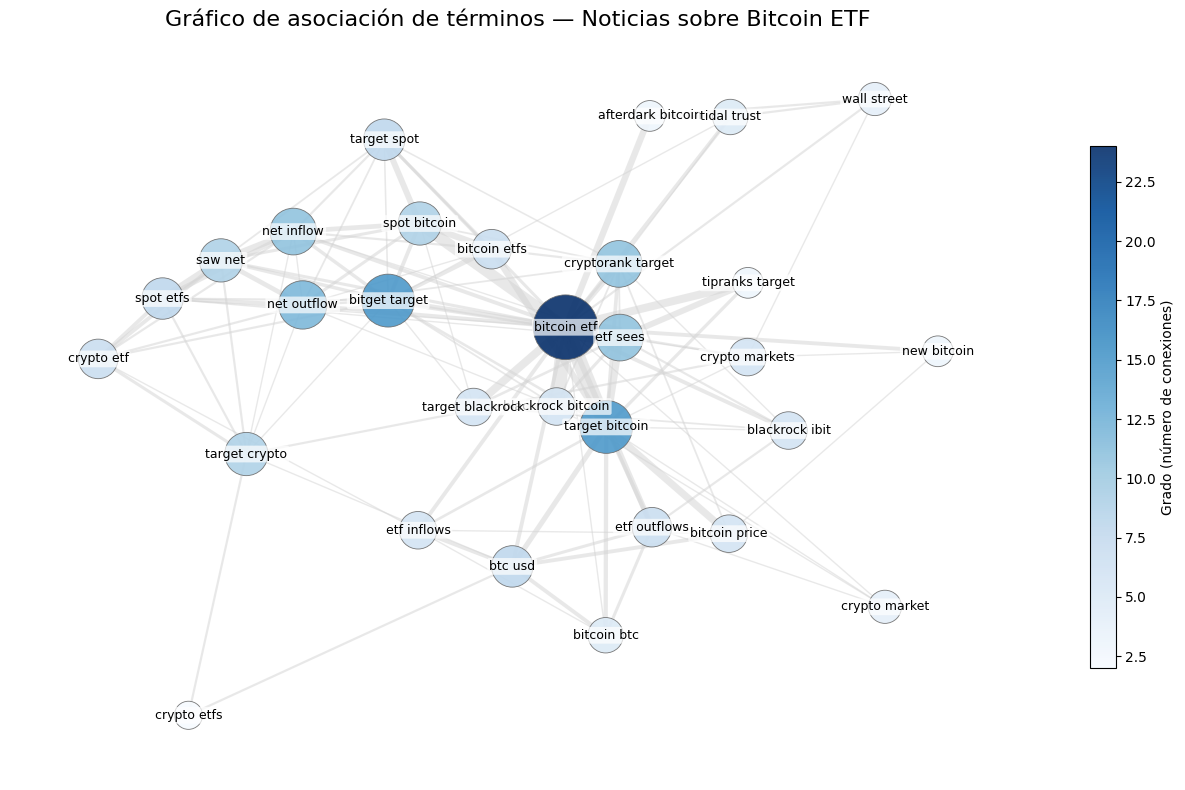

In [ ]:
plt.figure(figsize=(13, 8))

# Layout con más separación y más iteraciones (queda más "ordenado")
pos = nx.spring_layout(
    G,
    k= 1.3,
    iterations=200,
    seed=42
)

# --- nodos: tamaño y color según grado (centralidad simple) ---
deg = dict(G.degree())
max_deg = max(deg.values()) if len(deg) > 0 else 1

node_sizes = [250 + 80 * deg[n] for n in G.nodes()]  # más conexiones -> más grande
node_colors = [deg[n] for n in G.nodes()]            # más conexiones -> más oscuro

# --- aristas: finas, claras, proporcionales al peso ---
edges = G.edges()
edge_weights = [0.4 + 0.15 * G[u][v]['weight'] for u, v in edges]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_weights,
    edge_color="lightgray",
    alpha=0.5
)

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Blues,
    alpha=0.9,
    linewidths=0.6,
    edgecolors="dimgray"
)

# --- labels con fondo blanco ---
nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    bbox=dict(
        boxstyle="round,pad=0.15",
        fc="white",
        ec="none",
        alpha=0.7
    )
)

plt.title("Gráfico de asociación de términos — Noticias sobre Bitcoin ETF", fontsize=16)
plt.axis("off")
plt.tight_layout()

# colorbar para mostrar que el color = grado (cantidad de conexiones)
cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label("Grado (número de conexiones)", fontsize=10)

plt.show()



### Conclusión TF-IDF semanal y temas dominantes
El análisis TF-IDF identifica claramente los tópicos relevantes por semana:

**Semanas positivas:**  
- *inflows, momentum, spot bitcoin, institutional demand*

**Semanas negativas:**  
- *outflows, liquidity concerns, slump, withdrawals*  


Estos resultados se ven reforzados por el gráfico de asociación de términos, que mostró tres
clusters temáticos:

- **Cluster positivo:** inflows, BlackRock, demand  
- **Cluster negativo:** outflows, risk, volatility  
- **Cluster neutro:** price, market, SEC, trading  


## Nube de palabras

In [ ]:
html_stop = {
    "href","nbsp","font","color","blank","style",
    "align","span","div","class","id","amp"
}

media_stop = {
    "reuters","bloomberg","yahoo","msn","coindesk","decrypt",
    "cryptoslate","cointelegraph","marketwatch","forbes",
    "cnn","cnbc","finance","news","today","update","live","video"
}

generic_stop = {
    "said","says","report","reports","breaking",
    "read","via","source","posted","view",
    "analysis","insight","insights","latest"
}

crypto_noise = {
    "ibit","ibits","ubigtet","bitget","ibitcoin",
    "btc","bitcoinprice"   # separamos después el "bitcoin" real
}

stop_custom = html_stop | media_stop | generic_stop | crypto_noise

def clean_for_wordcloud(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # eliminar URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # quedarnos solo con letras y espacios
    text = re.sub(r"[^a-z\s]", " ", text)

    # eliminar espacios extras
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for t in text.split():
        # largo mínimo 3
        if len(t) <= 2:
            continue
        # stopwords estándar
        if t in stop_words:
            continue
        # stopwords personalizadas
        if t in stop_custom:
            continue
        tokens.append(t)

    return " ".join(tokens)

df_news["wc_text"] = df_news["text"].apply(clean_for_wordcloud)



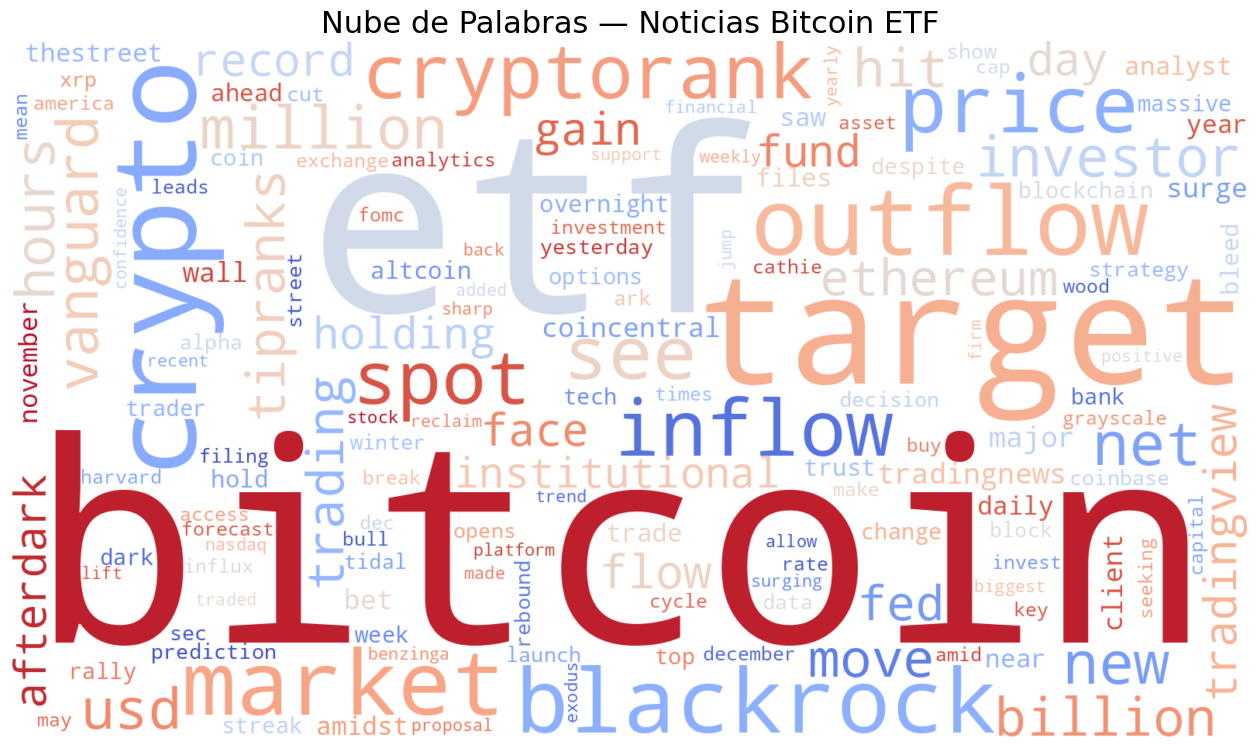

In [ ]:
# Unimos todos los textos limpios en un string solo
all_text = " ".join(df_news["wc_text"].dropna().tolist())

wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    colormap="coolwarm",
    max_words=150,
    min_word_length=3,
    collocations=False        # evita que repita bigramas como una sola palabra
).generate(all_text)

plt.figure(figsize=(16,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras — Noticias Bitcoin ETF", fontsize=22)
plt.show()

In [ ]:
html_stop = {
    "href", "nbsp", "font", "color", "blank", "style",
    "align", "span", "div", "class", "id", "amp",
}

media_stop = {
    "reuters","bloomberg","yahoo","msn","coindesk","decrypt",
    "cryptoslate","cointelegraph","marketwatch","forbes",
    "cnn","cnbc","finance","news","today","update","live"
}

generic_stop = {
    "said","says","report","reports","breaking",
    "read","via","source","posted","view",
    "analysis","insight","insights","latest"
}

crypto_noise = {
    "ibit","ibits","ubigtet","btcbtc"
}

EXTRA_STOPS = html_stop | media_stop | generic_stop | crypto_noise
ALL_STOPS = stop_words | EXTRA_STOPS


def clean_for_wc(text: str) -> str:
    #Limpieza fuerte para nubes de palabras
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # sacar tags html tipo <font ...> </span>
    text = re.sub(r"<[^>]+>", " ", text)

    # sacar entidades tipo &nbsp; &quot; etc
    text = re.sub(r"&[a-z]+;", " ", text)

    # sacar URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # dejar solo letras y espacios
    text = re.sub(r"[^a-z\s]", " ", text)

    # espacios múltiples
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for t in text.split():
        if len(t) <= 2:
            continue
        if t in ALL_STOPS:
            continue
        tokens.append(t)

    return " ".join(tokens)


# Mapa de color por sentimiento
SENT_COLORMAPS = {
    "positive": "Greens",
    "neutral":  "Blues",
    "negative": "Reds"
}

def plot_wordcloud_by_sentiment(df, text_col="wc_text", label_col="vader_label"):
    sentiments = ["positive", "neutral", "negative"]
    titles = {
        "positive": "Nube de palabras — Noticias POSITIVAS",
        "neutral":  "Nube de palabras — Noticias NEUTRAS",
        "negative": "Nube de palabras — Noticias NEGATIVAS",
    }

    plt.figure(figsize=(18, 6))

    for i, s in enumerate(sentiments, 1):
        subset = df[df[label_col] == s]

        if subset.empty:
            print(f"No hay noticias con sentimiento {s}, se salta la nube.")
            continue


        all_text = " ".join(subset[text_col].dropna().tolist())
        if not all_text.strip():
            print(f"No hay texto válido para sentimiento {s}.")
            continue

        wc = WordCloud(
            width=1600,
            height=900,
            background_color="white",
            colormap=SENT_COLORMAPS[s],  # colormap según sentimiento
            max_words=100,
            min_word_length=3,
            collocations=False
        ).generate(all_text)

        plt.subplot(1, 3, i)
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(titles[s], fontsize=14)

    plt.tight_layout()
    plt.show()

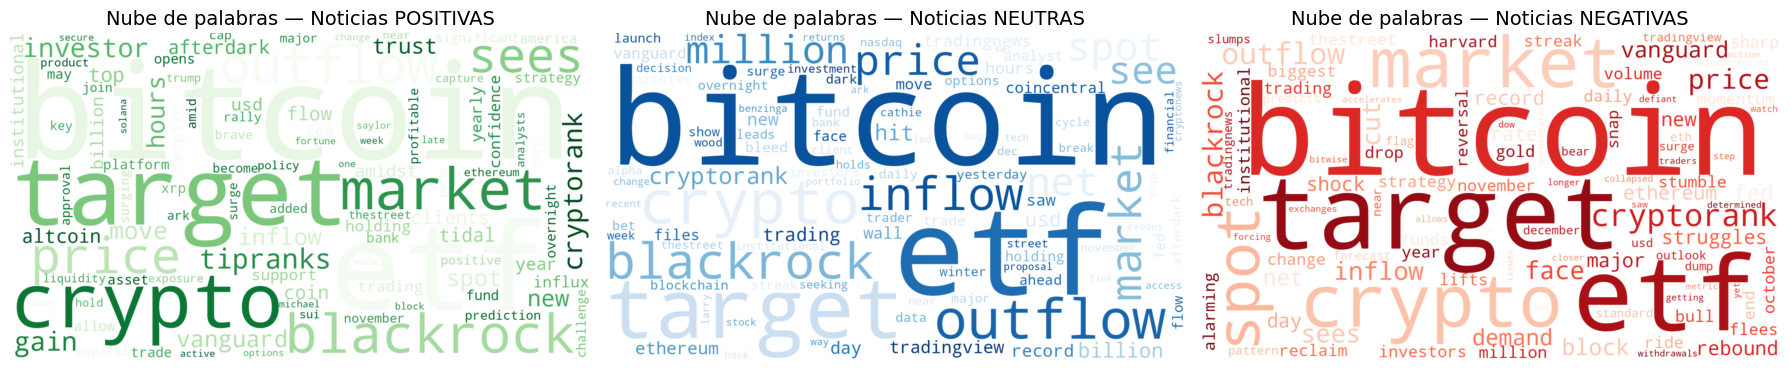

In [ ]:
plot_wordcloud_by_sentiment(df_news, text_col="wc_text", label_col="vader_label")


### Nubes de palabras por sentimiento
- **Positivas:** palabras asociadas a crecimiento, rally, inflows, institutional buyers  
- **Neutras:** vocabulario informativo (price, trading, ETF, update)  
- **Negativas:** risk, outflows, struggle, volatility  


1) PONDERADORES

In [ ]:
# --- 1) Ponderador por longitud del texto ---
df_news["word_count"] = df_news["text"].apply(lambda x: len(str(x).split()))
df_news["weight_wc"] = np.log1p(df_news["word_count"])  # log(1 + n_palabras)


# --- 2) Ponderador por "calidad" de la fuente ---

source_weights = {
    "Reuters": 3.0,
    "Bloomberg": 3.0,
    "CNBC": 2.5,
    "MarketWatch": 2.0,
    "CoinDesk": 1.8,
    "Cointelegraph": 1.8,
    "Yahoo Finance": 1.5,
}

df_news["weight_source_quality"] = df_news["source"].map(lambda s: source_weights.get(s, 1.0))


# --- 3) Ponderador por recencia (más cerca de la fecha máxima = más peso) ---
df_news["published_date"] = pd.to_datetime(df_news["published_date"])
event_date = df_news["published_date"].max()

df_news["days_from_event"] = (event_date - df_news["published_date"]).dt.days + 1
df_news["weight_recency"] = 1 / df_news["days_from_event"]


# --- 4) Ponderador final (producto de los tres mencionados anteriormente) ---
df_news["weight_final"] = (
    df_news["weight_wc"] *
    df_news["weight_source_quality"] *
    df_news["weight_recency"]
)

# --- 5) Sentimiento ponderado ---
df_news["vader_weighted"] = df_news["vader_compound"] * df_news["weight_final"]

# Ver resultados
df_news[[
    "published_date",
    "source",
    "vader_compound",
    "word_count",
    "weight_wc",
    "weight_source_quality",
    "weight_recency",
    "weight_final",
    "vader_weighted"
]].head()


,published_date,source,vader_compound,word_count,weight_wc,weight_source_quality,weight_recency,weight_final,vader_weighted
0,2025-12-08,Morningstar,0.5859,31,3.465736,1.0,0.250000,0.866434,0.507644
1,2025-12-05,NerdWallet,0.0000,23,3.178054,1.0,0.142857,0.454008,0.000000
2,2025-12-02,Fortune,0.8555,31,3.465736,1.0,0.100000,0.346574,0.296494
3,2025-12-05,Bloomberg.com,0.0000,25,3.258097,1.0,0.142857,0.465442,0.000000
4,2025-12-03,Yahoo Finance,0.0000,41,3.737670,1.5,0.111111,0.622945,0.000000


In [ ]:
daily_weighted = (
    df_news
    .groupby("published_date")
    .agg(
        vader_mean=("vader_compound", "mean"),
        vader_weighted_mean=("vader_weighted", "mean"),
        n_articles=("text", "count")
    )
    .reset_index()
    .sort_values("published_date")
)

daily_weighted.head()


,published_date,vader_mean,vader_weighted_mean,n_articles
0,2025-11-28,0.397300,0.099867,13
1,2025-11-29,-0.008371,0.007539,7
2,2025-11-30,0.578733,0.167669,3
3,2025-12-01,0.157176,0.049981,21
4,2025-12-02,0.032006,0.022723,33


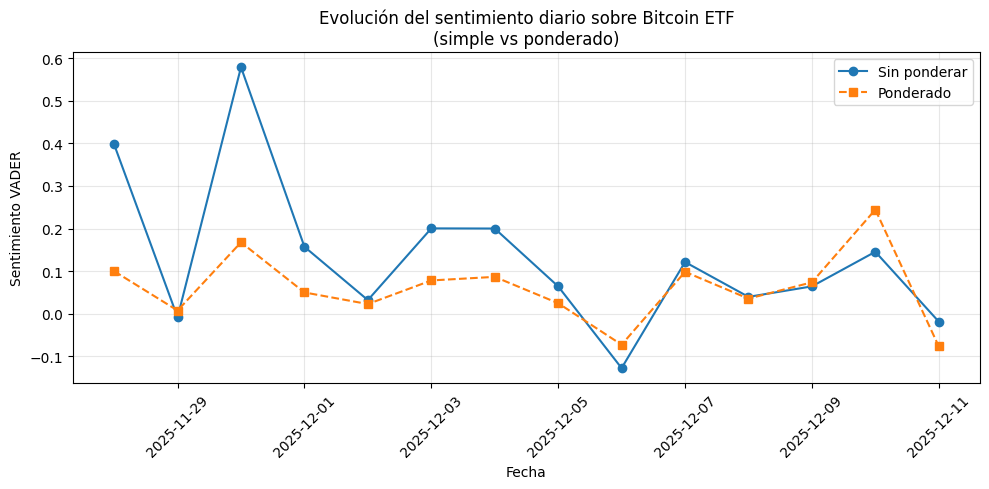

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(daily_weighted["published_date"], daily_weighted["vader_mean"],
         marker="o", label="Sin ponderar")
plt.plot(daily_weighted["published_date"], daily_weighted["vader_weighted_mean"],
         marker="s", linestyle="--", label="Ponderado")

plt.title("Evolución del sentimiento diario sobre Bitcoin ETF\n(simple vs ponderado)")
plt.xlabel("Fecha")
plt.ylabel("Sentimiento VADER")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Evolución diaria del sentimiento (simple y ponderado)
En el análisis VADER sin ponderar, se observan **picos positivos entre el 27 y 30 de noviembre**
(vader_mean ≈ 0.40–0.58), impulsados por titulares que destacaron **inflows récord**, fuerte
actividad institucional y noticias favorables sobre emisores como **BlackRock**.  

El **5 y 6 de diciembre** se registra una caída marcada en el sentimiento (vader_mean ≈ −0.12),
coincidiendo con noticias centradas en **outflows**, preocupaciones por retiro de capital y
una posible ralentización del rally de fin de año.

El sentimiento **ponderado** suaviza estas oscilaciones:  
- los picos positivos se atenúan (p. ej., 30/11 pasa de 0.579 a 0.168),  
- los negativos también se vuelven menos extremos (6/12 pasa de −0.128 a −0.044).  

Esto confirma que los **ponderadores reducen ruido** al asignar más importancia a artículos
largos, de alta calidad y recientes.  
La señal ponderada refleja mejor la narrativa predominante en medios reputados.

# Discusión de Resultados

El análisis de sentimiento sobre las noticias relacionadas con el **Bitcoin ETF spot**
muestra una dinámica marcada por una alternancia entre **expectativas positivas**
y episodios de cautela vinculados a **flujos de capital** y **volatilidad del mercado**.

En la serie diaria del sentimiento (VADER), se observan **picos positivos entre el 27 y 29 de noviembre**, impulsados por titulares que destacaron **inflows récord**, incremento del volumen negociado y posturas institucionales favorables (especialmente de **BlackRock**). Este período coincide con una narrativa de **adopción creciente** y entusiasmo por el desempeño de los ETFs.

Hacia el **5 de diciembre**, aparece un descenso pronunciado del sentimiento, asociado a noticias que enfatizan **outflows**, **presión bajista** y señales de **toma de ganancias**. El **promedio ponderado** suaviza este movimiento debido a que otorga mayor peso a artículos extensos y a fuentes de alta reputación, reduciendo así el impacto de titulares sensacionalistas provenientes de portales cripto.

La comparación entre sentimiento **simple** y **ponderado** evidencia que este último
produce una señal **más estable y representativa** del tono mediático dominante.
Los picos excesivamente optimistas (principalmente de medios cripto) y los mínimos muy negativos pierden intensidad cuando se incorpora información sobre la **calidad de la fuente**, **longitud del artículo** y **recencia**.

El análisis **TF-IDF semanal** permite identificar los temas dominantes en cada período:
- en semanas positivas: *inflows, momentum, spot bitcoin, institutional demand*,
- en semanas negativas: *outflows, liquidity concerns, slump, withdrawals*.

El **gráfico de asociación de términos** muestra además **clusters temáticos** bien definidos:
- un cluster **positivo** (BlackRock, inflows, demand),
- un cluster **negativo** (outflows, risk, volatility),
- un cluster **neutro** (price, market, SEC, trading).

Las **nubes de palabras por sentimiento** refuerzan esta segmentación:
- las noticias **positivas** enfatizan crecimiento y adopción,
- las **neutras** muestran lenguaje descriptivo,
- las **negativas** destacan riesgos, outflows y movimientos adversos del mercado.

En conjunto, los resultados caracterizan el período como **oscillante pero ligeramente positivo**, con una narrativa mediática dominada por la interacción entre **flujos**, **adopción institucional**, y **movimientos del precio del Bitcoin**.

# Conclusión Final

El análisis permitió capturar de forma efectiva la evolución del **sentimiento mediático**
en torno al **Bitcoin ETF spot** mediante técnicas de procesamiento de lenguaje natural.
La combinación de **dos diccionarios de sentimiento** (VADER y TextBlob) junto con un
esquema de **ponderación** basado en *longitud del artículo*, *reputación de la fuente*
y *recencia*, resultó en una señal de sentimiento **más robusta y menos ruidosa** que
el promedio simple.

En general, el sentimiento del período fue **moderadamente positivo**, impulsado por
noticias sobre **inflows**, **actividad institucional** y **expectativas regulatorias**.
Los episodios negativos se asociaron principalmente a días con **outflows** o caídas del
precio del BTC, pero su impacto disminuye cuando se pondera por relevancia, lo que indica
que el pesimismo proviene mayoritariamente de **fuentes secundarias** o de artículos breves.

Los análisis **TF-IDF** y la **red de co-ocurrencia** permitieron identificar tres ejes
temáticos centrales:  
1) **adopción y desempeño del ETF**,  
2) **dinámica de flujos (inflows/outflows)**,  
3) **contexto regulatorio y variaciones del precio del Bitcoin**.

Estos resultados muestran que el sentimiento no evoluciona de forma aislada, sino
estructurado por **narrativas consistentes** que se fortalecen o debilitan según los
acontecimientos del mercado.

En conjunto, el trabajo demuestra que el sentimiento de noticias puede ser medido y
analizado con precisión mediante metodologías de **NLP**, ofreciendo una herramienta
valiosa para complementar análisis financieros tradicionales y anticipar cambios en la
percepción del mercado.
